In [2]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

customer = pd.read_csv('customer_churn.csv')

print('Dataset shape:', customer.shape)
print()


customer.head(8)


Dataset shape: (50, 5)



,customer_id,age,monthly_spend,num_complaints,churned
0,CUST-001,60,2324,0,1
1,CUST-002,37,4512,3,0
2,CUST-003,28,12566,1,0
3,CUST-004,54,1924,6,1
4,CUST-005,22,988,1,1
5,CUST-006,33,4311,8,1
6,CUST-007,58,934,8,1
7,CUST-008,32,12231,8,1


In [3]:
x = customer[['age', 'monthly_spend',
              'num_complaints']]
y = customer['churned']

print("Feature (X) Shape: ", x.shape)
print(x.head(5))
print()
print("Label (y) - what we want to predict)")
print(y.values)
print(f"The number of customers who churned is: {y.sum()} | The number of customers who did not churn is: {len(y) - y.sum()}")

Feature (X) Shape:  (50, 3)
   age  monthly_spend  num_complaints
0   60           2324               0
1   37           4512               3
2   28          12566               1
3   54           1924               6
4   22            988               1

Label (y) - what we want to predict)
[1 0 0 1 1 1 1 1 1 0 1 0 1 1 1 0 0 1 1 0 0 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 0
 1 1 1 1 1 0 0 1 1 0 1 1 1]
The number of customers who churned is: 35 | The number of customers who did not churn is: 15


In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f'Training set:  {len(x_train)} customers')
print(f'Test set:  {len(x_test)} customers')
print()

model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)

print('Model trained. It has now seen', len(x_train), 'examples.')
print('It learned patterns - no rules were written by hand.')


Training set:  40 customers
Test set:  10 customers

Model trained. It has now seen 40 examples.
It learned patterns - no rules were written by hand.


In [5]:
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)

print('Test set predictions vs actual decisions:')
print(f'{"Actual":<10} {"ML Predicted":<15} {"Match?"}')
print('-' * 35)
for actual, predicted in zip(y_test, y_pred):
    match = 'YES' if actual == predicted else 'NO'
    label_a = 'APPROVED' if actual else'REJECTED'
    label_p = 'APPROVED' if predicted else 'REJECTED'
    print(f'{label_a:<10} {label_p:<15} {match}')

    print()
    print(f'Accuracy: {accuracy*100:.0f}%')


Test set predictions vs actual decisions:
Actual     ML Predicted    Match?
-----------------------------------
APPROVED   APPROVED        YES

Accuracy: 100%
APPROVED   APPROVED        YES

Accuracy: 100%
APPROVED   APPROVED        YES

Accuracy: 100%
APPROVED   APPROVED        YES

Accuracy: 100%
APPROVED   APPROVED        YES

Accuracy: 100%
APPROVED   APPROVED        YES

Accuracy: 100%
REJECTED   REJECTED        YES

Accuracy: 100%
APPROVED   APPROVED        YES

Accuracy: 100%
APPROVED   APPROVED        YES

Accuracy: 100%
REJECTED   REJECTED        YES

Accuracy: 100%


In [6]:
print('Supervised Learning - churn prediction results:')
print('Test accuracy:', round(accuracy * 100), '%')
print()
print('Predictions vs Actual:')

#Turn y_test into a normal list so we can count through it with a number
actual_list = list(y_test)

#Go through each customer one at a time, using a simple counter (i)

for i in range(len(actual_list)):
    actual_value = actual_list[i]
    predicted_value = y_pred[i]

    if actual_value == 1:
        actual_text = 'approved'
    else: 
        actual_text = 'rejected'

    if predicted_value == 1:   
        predicted_text = 'approved'
    else: 
        predicted_text = 'rejected'
    if actual_value == predicted_value:
        result = 'correct'
    else:
        result = 'wrong'
    print('customer', i + 1, '-> Actual:', actual_text, '| predicted:', predicted_text, '| Model was', result)                

Supervised Learning - churn prediction results:
Test accuracy: 100 %

Predictions vs Actual:
customer 1 -> Actual: approved | predicted: approved | Model was correct
customer 2 -> Actual: approved | predicted: approved | Model was correct
customer 3 -> Actual: approved | predicted: approved | Model was correct
customer 4 -> Actual: approved | predicted: approved | Model was correct
customer 5 -> Actual: approved | predicted: approved | Model was correct
customer 6 -> Actual: approved | predicted: approved | Model was correct
customer 7 -> Actual: rejected | predicted: rejected | Model was correct
customer 8 -> Actual: approved | predicted: approved | Model was correct
customer 9 -> Actual: approved | predicted: approved | Model was correct
customer 10 -> Actual: rejected | predicted: rejected | Model was correct


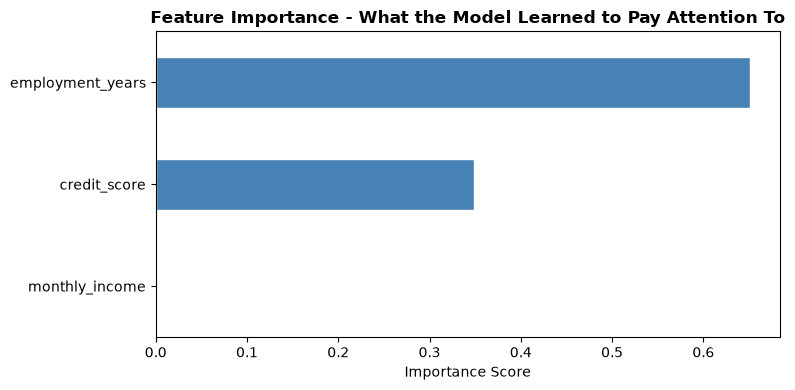

The model assigned importance to each feature based on the taining data.
The is the pattern it learned - no human specified thes weights


In [7]:
loan = pd.read_csv('loan_applicants.csv')
import matplotlib.pyplot as plt

#feature importance  - which feature mattered most to the model?

importance = pd.Series(model.feature_importances_, index=['monthly_income', 'credit_score', 'employment_years']).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importance.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importance - What the Model Learned to Pay Attention To', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('The model assigned importance to each feature based on the taining data.')
print('The is the pattern it learned - no human specified thes weights')